In [1]:
import os
import re
import sys
import glob
import toml
import shutil
import textwrap
import subprocess

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from astropy.io import fits
from importlib import reload
from astropy.table import Table
from scipy.interpolate import interp1d
from joebvp import cfg, utils, VPmeasure
from matplotlib.ticker import MultipleLocator

plt.rcParams['font.family'] = 'Times New Roman'

read_sets: Using set file -- 
  /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/lists/sets/llist_v1.3.ascii
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/morton03_table2.fits.gz
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/linetools/data/lines/verner96_tab1.fits.gz
joebvp.makevoigt: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
joebvp.VPmeasure: No local joebvp_cfg.py found, using default cfg.py file from joebvp.
Loading abundances from Asplund2009
Abundances are relative by number on a logarithmic scale with H=12
linetools.lists.parse: Reading linelist --- 
   /Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-package

In [2]:
main_directory = Path().resolve()
# target_directories = ['/Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/BAT99 114', '/Users/billyli/Documents/float-for-morrow/LMC/LMC N11B/BI 42', '/Users/billyli/Documents/float-for-morrow/SMC/SMC N66A/Cl* NGC 346 NMC 17', '/Users/billyli/Documents/float-for-morrow/SMC/SMC N88A/2dFS 3694']

target_directories = ['/Users/billyli/Documents/float-for-morrow/LMC/30 Doradus/BAT99 114', '/Users/billyli/Documents/float-for-morrow/LMC/LMC N11B/BI 42', '/Users/billyli/Documents/float-for-morrow/SMC/SMC N66A/Cl* NGC 346 NMC 17', '/Users/billyli/Documents/float-for-morrow/SMC/SMC N66A/Cl* NGC 346 MPG 782']

spectra_directories_1 = sorted([d for d in os.listdir(target_directories[0]) if d.startswith("G") or d.startswith("E")])
spectra_directories_2 = sorted([d for d in os.listdir(target_directories[1]) if d.startswith("G") or d.startswith("E")])
spectra_directories_3 = sorted([d for d in os.listdir(target_directories[2]) if d.startswith("G") or d.startswith("E")])
spectra_directories_4 = sorted([d for d in os.listdir(target_directories[3]) if d.startswith("G") or d.startswith("E")])
# galaxy = target_directory.parts[target_directory.parts.index('float-for-morrow') + 1]
# region = target_directory.parts[target_directory.parts.index("float-for-morrow") + 2]
# target = target_directory.name
# print(spectra_directories)
# print(galaxy)
# print(region)

In [3]:
def parse_directory(dirname, Target):

    parts = dirname.split("_")

    Grating = parts[0]
    Cenwave = int(parts[1])
    T_exp = str(parts[3])
    PID = int(parts[4])

    if Grating.startswith("G"):
        
        Instrument = "COS"
        LP = parts[2]

        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": LP, 
            "Aperture": None, 
            "T_exp": T_exp, 
            "PID": PID, 
        }
        
    else:
        
        Instrument = "STIS"
        Aperture = parts[2]
        return {
            "Target": Target, 
            "Instrument": Instrument, 
            "Grating": Grating, 
            "Cenwave": Cenwave, 
            "LP": None, 
            "Aperture": Aperture, 
            "T_exp": T_exp, 
            "PID": PID, 
        }

records = [parse_directory(d, 'BAT99 114') for d in spectra_directories_1]
df_1 = pd.DataFrame.from_records(records)
records = [parse_directory(d, 'BI 42') for d in spectra_directories_2]
df_2 = pd.DataFrame.from_records(records)
records = [parse_directory(d, 'Cl* NGC 346 NMC 17') for d in spectra_directories_3]
df_3 = pd.DataFrame.from_records(records)
records = [parse_directory(d, 'Cl* NGC 346 MPG 782') for d in spectra_directories_4]
df_4 = pd.DataFrame.from_records(records)
display(df_1)

,Target,Instrument,Grating,Cenwave,LP,Aperture,T_exp,PID
0,BAT99 114,COS,G130M,1291,LP5,None,2072.416,16812
1,BAT99 114,COS,G160M,1611,LP6,None,2024.096,16812


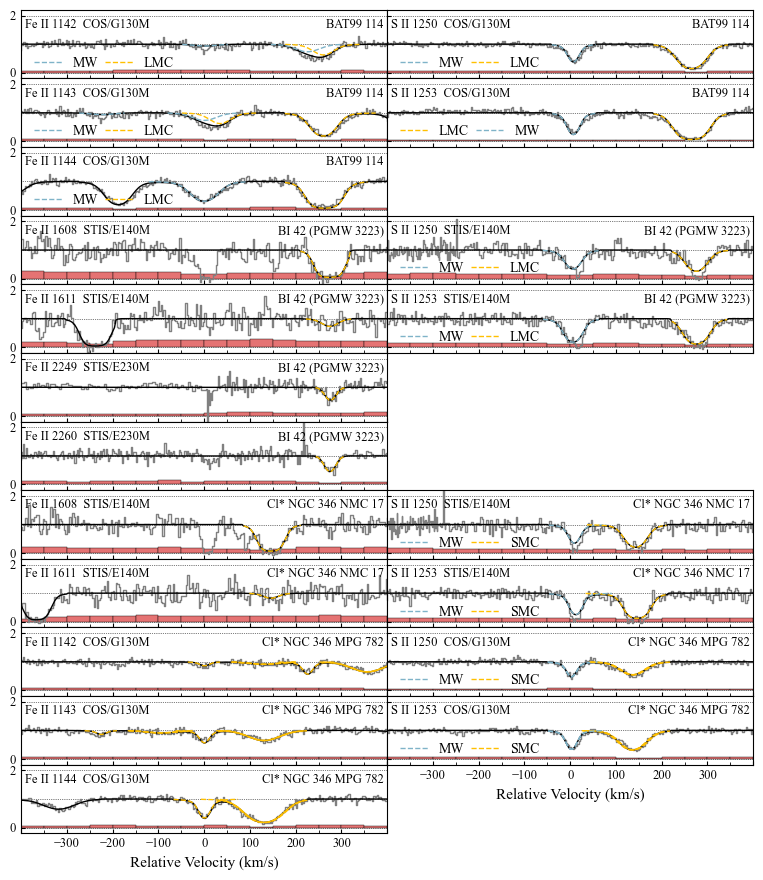

In [4]:
LINESETS = {
    "E230M": [
        dict(label = "Fe II 2249; Fe II 2260",
             wrest_for_vel = 2260.7805,
             lines = [2249.8768, 2260.7805]),
    ],
    "E140M": [
        dict(label = "Fe II 1608; Fe II 1611",
             wrest_for_vel = 1611.2005,
             lines = [1608.4511, 1611.2005]),
        dict(label = "S II 1250",
             wrest_for_vel = 1250.5840,
             lines = [1250.5840]),
        dict(label = "S II 1253",
             wrest_for_vel = 1253.8110,
             lines = [1253.8110]),
    ],
    "G130M": [
        dict(label = "Fe II 1142; Fe II 1143; Fe II 1144",
             wrest_for_vel = 1143.2260,  # pick one; adjust if you prefer the other
             lines = [1142.3660, 1143.2260, 1144.9379]),
        dict(label = "S II 1250",
             wrest_for_vel = 1250.5840,
             lines = [1250.5840]),
        dict(label = "S II 1253",
             wrest_for_vel = 1253.8110,
             lines = [1253.8110]),
    ],
}

def parse_partial_meta(fname):
    z = None
    wrest = None
    m = re.search(r"_z([0-9]+\.[0-9]+)\.fits$", fname)
    if m:
        z = float(m.group(1))
    m = re.search(r"_w([0-9]+\.[0-9]+)_z", fname)
    if m:
        wrest = float(m.group(1))
    return z, wrest

def wave_to_vel(w, wrest, c_kms = 299792.458):
    return c_kms * (w / wrest - 1.0)

def vel_to_wave(v, wrest, c_kms = 299792.458):
    return wrest * (1.0 + v / c_kms)

def read_norm_spectrum(fitinsp_path, contfit_path):
    with fits.open(fitinsp_path) as h1, fits.open(contfit_path) as h2:
        w1 = h1["WAVELENGTH"].data.astype(float)
        f1 = h1["FLUX"].data.astype(float)
        c1 = h1["CONTINUUM"].data.astype(float)
        e1 = h1["ERROR"].data.astype(float)

        w2 = h2["WAVELENGTH"].data.astype(float)
        f2 = h2["FLUX"].data.astype(float)
        c2 = h2["CONTINUUM"].data.astype(float)
        e2 = h2["ERROR"].data.astype(float)

    f1n = f1 / np.where(c1 == 0, np.nan, c1)
    e1n = e1 / np.where(c1 == 0, np.nan, c1)
    f2n = f2 / np.where(c2 == 0, np.nan, c2)
    e2n = e2 / np.where(c2 == 0, np.nan, c2)

    mask = np.isfinite(w1) & np.isfinite(f1n) & np.isfinite(f2n)
    return w1[mask], f1n[mask], e1n[mask], f2n[mask], e2n[mask]

def style_axis(ax, xlim = (-400, 400), ylim = (0, 2), labelsize = 10):
    ax.set_xlim(*xlim)
    ax.set_ylim(*ylim)
    ax.tick_params(axis = "both", which = "major", labelsize = labelsize)

LINE_COLS = [
    dict(label = "Fe II 1142", wrest = 1142.3660),
    dict(label = "Fe II 1143", wrest = 1143.2260),
    dict(label = "Fe II 1144", wrest = 1144.9379),
    dict(label = "Fe II 1608", wrest = 1608.4511),
    dict(label = "Fe II 1611", wrest = 1611.2005),
    dict(label = "Fe II 2249", wrest = 2249.8768),
    dict(label = "Fe II 2260", wrest = 2260.7805),
    dict(label = "S II 1250",  wrest = 1250.5840),
    dict(label = "S II 1253",  wrest = 1253.8110),
]

c_kms = 299792.458
X_LIM = (-400, 400)
Y_LIM = (-0.2, 2.2)
COVERAGE_PAD_A = 0.5
WREST_MATCH_TOL_A = 1.0

ALLOWED_LINES_BY_GRATING = {}
for grat, panel_list in LINESETS.items():
    allowed = []
    for p in panel_list:
        allowed.extend(p["lines"])
    ALLOWED_LINES_BY_GRATING[grat] = np.array(sorted(set(allowed)), dtype = float)

def grating_allows_line(grating, wrest, tol = 1e-3):
    if grating not in ALLOWED_LINES_BY_GRATING:
        return False
    return np.any(np.abs(ALLOWED_LINES_BY_GRATING[grating] - wrest) < tol)

gratings = []
gratings = set()

spectra_items = []
for i in range(len(spectra_directories_1)):
    directory = spectra_directories_1[i]
    path = os.path.join(target_directories[0], directory)

    instrument = df_1.loc[i, "Instrument"]
    grating = df_1.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if grating in gratings:
        continue

    for subdir in os.listdir(path):
        subdir_path = Path(os.path.join(path, subdir))

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory = directory,
            subdir = subdir,
            subdir_path = subdir_path,
            contfit_path = cont_matches[0],
            fitinsp_path = fitinsp_matches[0],
            partial_paths = list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument = instrument,
            grating = grating,
        ))

spectra_items.sort(key = lambda d: (d["grating"], d["subdir"]))

panels = []

for line in LINE_COLS:
    wrest = line["wrest"]

    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue

        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)
        w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
        w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A

        if (wmax < w_lo) or (wmin > w_hi):
            continue

        panels.append((line, item))

panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue
        panels.append((line, item))

N = len(panels)
ncols = 2
nrows = 12

fig, ax_grid = plt.subplots(
    nrows = nrows, ncols = 2,
    figsize = (8, 0.75 * nrows),
    sharex = "col",
    sharey = True
)

axes = np.array(ax_grid).reshape(nrows, ncols).flatten(order = "F")

for ax in axes:
    ax.tick_params(axis = "y", which = "both", direction = "in", left = True, right = False, length = 3, width = 0.8)

major = MultipleLocator(100)
minor = MultipleLocator(50)

for ax in axes:
    ax.xaxis.set_major_locator(major)
    ax.xaxis.set_minor_locator(minor)
    ax.tick_params(axis = "x", which = "major", bottom = True, top = False,
                   length = 3, width = 0.8, direction = "in", labelbottom = False)
    ax.tick_params(axis = "x", which = "minor", bottom = True, top = False,
                   length = 2, width = 0.6, direction = "in", labelbottom = False)

cur_row_left = 0
cur_row_right = 0

for i, panel in enumerate(panels):

    line, item = panel

    if line['label'].startswith("S"):
        cur_col = 1
        ax = ax_grid[cur_row_right, cur_col]
        cur_row_right += 1
    else:
        cur_col = 0
        ax = ax_grid[cur_row_left, cur_col]
        cur_row_left += 1

    wrest = line["wrest"]

    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle = "steps-mid", lw = 1.0, color = "0.5")
    ax.plot(v, f1n, lw = 1.0, color = "0")
    
    bin_edges = np.arange(X_LIM[0], X_LIM[1] + 50, 50)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)
    
    m = np.isfinite(v) & np.isfinite(e2n) & (v >= X_LIM[0]) & (v <= X_LIM[1])
    vb = v[m]
    eb = e2n[m]
    
    inds = np.digitize(vb, bin_edges) - 1
    nbins = len(bin_centers)
    err_binned = np.full(nbins, np.nan)
    
    for k in range(nbins):
        ek = eb[inds == k]
        if ek.size == 0:
            continue
        err_binned[k] = np.nanmedian(ek)
    
    good = np.isfinite(err_binned)
    ax.bar(bin_centers[good], err_binned[good], width = bin_widths[good], bottom = 0.0, align = "center", color = "#E57373",  edgecolor = "0", linewidth = 0.3, zorder = 0)

    has_label_mw = False
    has_label_mc = False
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "#7FB3C8" if (z_partial is not None and z_partial < 0.0002) else "#FFC000"
        labl = "MW" if (z_partial is not None and z_partial < 0.0002) else "LMC"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        if has_label_mw == False and labl == "MW":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mw = True
        elif has_label_mc == False and labl == "LMC":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mc = True
        else:
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr)

    style_axis(ax, xlim = X_LIM, ylim = Y_LIM, labelsize = 9)

    for y in (0, 1, 2):
        ax.axhline(y, ls = ":", lw = 0.5, color = "0", zorder = 0)

    ax.text(
        0.01, 0.78,
        f"{line['label']}  {item['instrument']}/{item['grating']}",
        transform = ax.transAxes, ha = "left", va = "center", fontsize = 9
    )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[::-1], labels[::-1], ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)

    ax.text(0.99, 0.78, f"{'BAT99 114'}", transform = ax.transAxes, ha = "right", va = "center", fontsize = 9)

gratings = []
gratings = set()

spectra_items = []
for i in range(len(spectra_directories_2)):
    directory = spectra_directories_2[i]
    path = os.path.join(target_directories[1], directory)

    instrument = df_2.loc[i, "Instrument"]
    grating = df_2.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if grating in gratings:
        continue
    gratings.add(grating)

    for subdir in os.listdir(path):
        subdir_path = Path(os.path.join(path, subdir))

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory = directory,
            subdir = subdir,
            subdir_path = subdir_path,
            contfit_path = cont_matches[0],
            fitinsp_path = fitinsp_matches[0],
            partial_paths = list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument = instrument,
            grating = grating,
        ))

spectra_items.sort(key = lambda d: (d["grating"], d["subdir"]))

panels = []

for line in LINE_COLS:
    wrest = line["wrest"]

    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue

        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)
        w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
        w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A

        if (wmax < w_lo) or (wmin > w_hi):
            continue

        panels.append((line, item))

panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue
        panels.append((line, item))

cur_row_left = 3
cur_row_right = 3

for i, panel in enumerate(panels):

    line, item = panel

    if line['label'].startswith("S"):
        cur_col = 1
        ax = ax_grid[cur_row_right, cur_col]
        cur_row_right += 1
    else:
        cur_col = 0
        ax = ax_grid[cur_row_left, cur_col]
        cur_row_left += 1

    wrest = line["wrest"]

    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle = "steps-mid", lw = 1.0, color = "0.5")
    ax.plot(v, f1n, lw = 1.0, color = "0")
    
    bin_edges = np.arange(X_LIM[0], X_LIM[1] + 50, 50)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)
    
    m = np.isfinite(v) & np.isfinite(e2n) & (v >= X_LIM[0]) & (v <= X_LIM[1])
    vb = v[m]
    eb = e2n[m]
    
    inds = np.digitize(vb, bin_edges) - 1
    nbins = len(bin_centers)
    err_binned = np.full(nbins, np.nan)
    
    for k in range(nbins):
        ek = eb[inds == k]
        if ek.size == 0:
            continue
        err_binned[k] = np.nanmedian(ek)
    
    good = np.isfinite(err_binned)
    ax.bar(bin_centers[good], err_binned[good], width = bin_widths[good], bottom = 0.0, align = "center", color = "#E57373",  edgecolor = "0", linewidth = 0.3, zorder = 0)

    has_label_mw = False
    has_label_mc = False
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "#7FB3C8" if (z_partial is not None and z_partial < 0.0002) else "#FFC000"
        labl = "MW" if (z_partial is not None and z_partial < 0.0002) else "LMC"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        if has_label_mw == False and labl == "MW":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mw = True
        elif has_label_mc == False and labl == "LMC":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mc = True
        else:
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr)

    style_axis(ax, xlim = X_LIM, ylim = Y_LIM, labelsize = 9)

    for y in (0, 1, 2):
        ax.axhline(y, ls = ":", lw = 0.5, color = "0", zorder = 0)

    ax.text(
        0.01, 0.78,
        f"{line['label']}  {item['instrument']}/{item['grating']}",
        transform = ax.transAxes, ha = "left", va = "center", fontsize = 9
    )

    handles, labels = ax.get_legend_handles_labels()
    if labels[0] != "MW" and len(labels) == 2:
        ax.legend(handles[::-1], labels[::-1], ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)
    elif len(labels) == 2:
        ax.legend(handles, labels, ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)

    ax.text(0.99, 0.78, f"{'BI 42 (PGMW 3223)'}", transform = ax.transAxes, ha = "right", va = "center", fontsize = 9)

gratings = []
gratings = set()

spectra_items = []
for i in range(len(spectra_directories_3)):
    directory = spectra_directories_3[i]
    path = os.path.join(target_directories[2], directory)

    instrument = df_3.loc[i, "Instrument"]
    grating = df_3.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if grating in gratings:
        continue
    gratings.add(grating)

    for subdir in os.listdir(path):
        subdir_path = Path(os.path.join(path, subdir))

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory = directory,
            subdir = subdir,
            subdir_path = subdir_path,
            contfit_path = cont_matches[0],
            fitinsp_path = fitinsp_matches[0],
            partial_paths = list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument = instrument,
            grating = grating,
        ))

spectra_items.sort(key = lambda d: (d["grating"], d["subdir"]))

panels = []

for line in LINE_COLS:
    wrest = line["wrest"]

    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue

        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)
        w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
        w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A

        if (wmax < w_lo) or (wmin > w_hi):
            continue

        panels.append((line, item))

panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue
        panels.append((line, item))
   
cur_row_left = 7
cur_row_right = 7

for i, panel in enumerate(panels):

    line, item = panel

    if line['label'].startswith("S"):
        cur_col = 1
        ax = ax_grid[cur_row_right, cur_col]
        cur_row_right += 1
    else:
        cur_col = 0
        ax = ax_grid[cur_row_left, cur_col]
        cur_row_left += 1

    wrest = line["wrest"]

    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle = "steps-mid", lw = 1.0, color = "0.5")
    ax.plot(v, f1n, lw = 1.0, color = "0")
    
    bin_edges = np.arange(X_LIM[0], X_LIM[1] + 50, 50)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)
    
    m = np.isfinite(v) & np.isfinite(e2n) & (v >= X_LIM[0]) & (v <= X_LIM[1])
    vb = v[m]
    eb = e2n[m]
    
    inds = np.digitize(vb, bin_edges) - 1
    nbins = len(bin_centers)
    err_binned = np.full(nbins, np.nan)
    
    for k in range(nbins):
        ek = eb[inds == k]
        if ek.size == 0:
            continue
        err_binned[k] = np.nanmedian(ek)
    
    good = np.isfinite(err_binned)
    ax.bar(bin_centers[good], err_binned[good], width = bin_widths[good], bottom = 0.0, align = "center", color = "#E57373",  edgecolor = "0", linewidth = 0.3, zorder = 0)

    has_label_mw = False
    has_label_mc = False
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "#7FB3C8" if (z_partial is not None and z_partial < 0.0002) else "#FFC000"
        labl = "MW" if (z_partial is not None and z_partial < 0.0002) else "SMC"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        if has_label_mw == False and labl == "MW":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mw = True
        elif has_label_mc == False and labl == "SMC":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mc = True
        else:
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr)

    style_axis(ax, xlim = X_LIM, ylim = Y_LIM, labelsize = 9)

    for y in (0, 1, 2):
        ax.axhline(y, ls = ":", lw = 0.5, color = "0", zorder = 0)

    ax.text(
        0.01, 0.78,
        f"{line['label']}  {item['instrument']}/{item['grating']}",
        transform = ax.transAxes, ha = "left", va = "center", fontsize = 9
    )

    handles, labels = ax.get_legend_handles_labels()
    if labels[0] != "MW" and len(labels) == 2:
        ax.legend(handles[::-1], labels[::-1], ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)
    elif len(labels) == 2:
        ax.legend(handles, labels, ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)

    ax.text(0.99, 0.78, f"{'Cl* NGC 346 NMC 17'}", transform = ax.transAxes, ha = "right", va = "center", fontsize = 9)

gratings = []
gratings = set()

spectra_items = []
for i in range(len(spectra_directories_4)):
    directory = spectra_directories_4[i]
    path = os.path.join(target_directories[3], directory)

    instrument = df_4.loc[i, "Instrument"]
    grating = df_4.loc[i, "Grating"]

    if grating not in LINESETS:
        continue
    if grating in gratings:
        continue
    gratings.add(grating)

    for subdir in os.listdir(path):
        subdir_path = Path(os.path.join(path, subdir))

        cont_matches = list(subdir_path.glob("*_continuumfit.fits"))
        fitinsp_matches = list(subdir_path.glob("FitInspection.fits"))
        if not cont_matches or not fitinsp_matches:
            continue

        spectra_items.append(dict(
            directory = directory,
            subdir = subdir,
            subdir_path = subdir_path,
            contfit_path = cont_matches[0],
            fitinsp_path = fitinsp_matches[0],
            partial_paths = list(subdir_path.glob("FitInspection_partial_*.fits")),
            instrument = instrument,
            grating = grating,
        ))

spectra_items.sort(key = lambda d: (d["grating"], d["subdir"]))

panels = []

for line in LINE_COLS:
    wrest = line["wrest"]

    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue

        try:
            w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
        except Exception:
            continue

        wmin, wmax = np.nanmin(w), np.nanmax(w)
        w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
        w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A

        if (wmax < w_lo) or (wmin > w_hi):
            continue

        panels.append((line, item))

panels = []
for line in LINE_COLS:
    wrest = line["wrest"]
    for item in spectra_items:
        if not grating_allows_line(item["grating"], wrest, tol = 1e-3):
            continue
        panels.append((line, item))
    
cur_row_left = 9
cur_row_right = 9

for i, panel in enumerate(panels):

    line, item = panel

    if line['label'].startswith("S"):
        cur_col = 1
        ax = ax_grid[cur_row_right, cur_col]
        cur_row_right += 1
    else:
        cur_col = 0
        ax = ax_grid[cur_row_left, cur_col]
        cur_row_left += 1

    wrest = line["wrest"]

    try:
        w, f1n, e1n, f2n, e2n = read_norm_spectrum(item["fitinsp_path"], item["contfit_path"])
    except Exception:
        ax.axis("off")
        continue

    wmin, wmax = np.nanmin(w), np.nanmax(w)
    w_lo = vel_to_wave(X_LIM[0], wrest, c_kms) - COVERAGE_PAD_A
    w_hi = vel_to_wave(X_LIM[1], wrest, c_kms) + COVERAGE_PAD_A
    if (wmax < w_lo) or (wmin > w_hi):
        ax.axis("off")
        continue

    v = wave_to_vel(w, wrest, c_kms)
    ax.plot(v, f2n, drawstyle = "steps-mid", lw = 1.0, color = "0.5")
    ax.plot(v, f1n, lw = 1.0, color = "0")
    
    bin_edges = np.arange(X_LIM[0], X_LIM[1] + 50, 50)
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    bin_widths = np.diff(bin_edges)
    
    m = np.isfinite(v) & np.isfinite(e2n) & (v >= X_LIM[0]) & (v <= X_LIM[1])
    vb = v[m]
    eb = e2n[m]
    
    inds = np.digitize(vb, bin_edges) - 1
    nbins = len(bin_centers)
    err_binned = np.full(nbins, np.nan)
    
    for k in range(nbins):
        ek = eb[inds == k]
        if ek.size == 0:
            continue
        err_binned[k] = np.nanmedian(ek)
    
    good = np.isfinite(err_binned)
    ax.bar(bin_centers[good], err_binned[good], width = bin_widths[good], bottom = 0.0, align = "center", color = "#E57373",  edgecolor = "0", linewidth = 0.3, zorder = 0)

    has_label_mw = False
    has_label_mc = False
    for ppath in item["partial_paths"]:
        z_partial, wrest_partial = parse_partial_meta(ppath.name)
        if wrest_partial is None:
            continue
        if abs(wrest_partial - wrest) > WREST_MATCH_TOL_A:
            continue

        try:
            with fits.open(ppath) as hp:
                wp = hp["WAVELENGTH"].data.astype(float)
                mp = hp["FLUX"].data.astype(float)
        except Exception:
            continue

        goodp = np.isfinite(wp) & np.isfinite(mp)
        wp, mp = wp[goodp], mp[goodp]
        vp = wave_to_vel(wp, wrest, c_kms)

        colr = "#7FB3C8" if (z_partial is not None and z_partial < 0.0002) else "#FFC000"
        labl = "MW" if (z_partial is not None and z_partial < 0.0002) else "SMC"
        mp_plot = mp.copy()
        mp_plot[np.abs(mp_plot - 1) <= 1e-2] = np.nan
        if has_label_mw == False and labl == "MW":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mw = True
        elif has_label_mc == False and labl == "SMC":
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr, label = labl)
            has_label_mc = True
        else:
            ax.plot(vp, mp_plot, lw = 1, ls = "--", color = colr)

    style_axis(ax, xlim = X_LIM, ylim = Y_LIM, labelsize = 9)

    for y in (0, 1, 2):
        ax.axhline(y, ls = ":", lw = 0.5, color = "0", zorder = 0)

    ax.text(
        0.01, 0.78,
        f"{line['label']}  {item['instrument']}/{item['grating']}",
        transform = ax.transAxes, ha = "left", va = "center", fontsize = 9
    )

    handles, labels = ax.get_legend_handles_labels()
    if labels[0] != "MW" and len(labels) == 2:
        ax.legend(handles[::-1], labels[::-1], ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)
    elif len(labels) == 2:
        ax.legend(handles, labels, ncol = 2, loc = 'lower left', bbox_to_anchor = (0, -0.05), columnspacing = 0.5, frameon = False)

    # ax.text(0.99, 0.78, f"{'2dFS 3694'}", transform = ax.transAxes, ha = "right", va = "center", fontsize = 9)
    ax.text(0.99, 0.78, f"{'Cl* NGC 346 MPG 782'}", transform = ax.transAxes, ha = "right", va = "center", fontsize = 9)

ax_grid[11, 0].tick_params(axis = "x", which = "major", labelbottom = True)
ax_grid[11, 0].set_xlabel("Relative Velocity (km/s)", fontsize = 11)
ax_grid[10, 1].tick_params(axis = "x", which = "major", labelbottom = True)
ax_grid[10, 1].set_xlabel("Relative Velocity (km/s)", fontsize = 11)

ax_grid[2, 1].axis("off")
ax_grid[5, 1].axis("off")
ax_grid[6, 1].axis("off")
ax_grid[11, 1].axis("off")

fig.subplots_adjust(left = 0.08, right = 0.995, bottom = 0.06, top = 0.975, hspace = 0.0, wspace = 0.0)

for ax in axes:
    ticks = ax.get_xticks()
    labels = ax.get_xticklabels()

    for t, lab in zip(ticks, labels):
        if np.isclose(t, X_LIM[1]):
            lab.set_visible(False)
        if np.isclose(t, X_LIM[0]):
            lab.set_visible(False)

outfile = f"/Users/billyli/Documents/float-for-morrow/spectra_plots.png"
fig.savefig(outfile, dpi = 300, bbox_inches = "tight")
plt.show()
plt.close(fig)